# Project 1 — Celebrity Classification
## Milestone 1: Model Comparison on a 5-Class CelebA Subset

**IE 7615** — Project 1, Milestone 1

**David Fung**

This milestone trains and compares three image-classification architectures on a curated subset of the CelebA dataset (5 identities). The models are: (1) a custom CNN built from scratch, (2) a ResNet50 transfer-learning baseline in feature-extraction mode, and (3) the same ResNet50 backbone with the final convolutional block unfrozen for fine-tuning. All experiments are conducted in a single notebook.

In [84]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D,
    Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array, to_categorical
from sklearn.model_selection import train_test_split

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.13.1


In [85]:
# PROJECT CONSTANTS
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
tf.keras.utils.set_random_seed(GLOBAL_SEED)

def set_all_seeds():
    np.random.seed(GLOBAL_SEED)
    tf.random.set_seed(GLOBAL_SEED)

BATCH = 16
EPOCHS = 30
EPOCH_SETPOINT = [5, 10, 15, 20, 25, 30]
VSPLIT = 0.2

IMG_SIZE = (224, 224)
NUM_CLASSES = 5
CLASS_NAMES = ['7', '797', '2619', '4428', '7007']
DATA_DIR = "data/selected_images"

In [86]:
def plot_history(history, title):
    # Identify overfitting point: where val_acc peaks
    val_acc_series = history.history['val_accuracy']
    peak_epoch = val_acc_series.index(max(val_acc_series)) + 1
    
    epochs_all = range(1, EPOCHS+1)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the chart
    ax.plot(epochs_all, history.history['val_accuracy'], color='steelblue', label='Validation Accuracy')
    ax.plot(epochs_all, history.history['accuracy'], marker='o', color='orange', label='Train Accuracy')
    
    # Mark the required checkpoints
    val_acc_at_cp = [history.history['val_accuracy'][e - 1] for e in EPOCH_SETPOINT]
    train_acc_at_cp = [history.history['accuracy'][e - 1] for e in EPOCH_SETPOINT]
    
    ax.plot(EPOCH_SETPOINT, val_acc_at_cp, 'bo', markersize=8, label='Checkpoint (Validation)')
    ax.plot(EPOCH_SETPOINT, train_acc_at_cp, 'ro', markersize=8, label='Checkpoint (Train)')
    
    # Annotate the peak
    ax.axvline(peak_epoch, color='red', linestyle=':', alpha=0.6)
    ax.annotate(f'Peak Validation\nEpoch: {peak_epoch}\nVal Acc: {max(val_acc_series):.4f}',
                xy=(peak_epoch, max(val_acc_series)),
                xytext=(peak_epoch + 2, max(val_acc_series) - 0.05),
                arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

    # Plot Info
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f"{title}: {EPOCHS} Epoch Training")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Task 1 — Load and Preprocess

Load the 5-class CelebA subset (24–25 images per identity) from `data/selected_images/`. Each subdirectory is named after the CelebA ID. Images are resized to 224×224, rescaled to [0, 1], and split into train (70%), validation (15%), and test (15%) sets using a stratified split to preserve class balance.

**Preprocessing Pipeline:**
1. **Resize** — All images resized to 224×224 using bilinear interpolation (`load_img`)
2. **Normalize** — Pixel values scaled from [0, 255] to [0, 1] via division by 255.0
3. **Augment (train only)** — Random horizontal flip (50% probability), random brightness (±0.2), random contrast (0.8–1.2×), random saturation (0.8–1.2×)
4. **Validation/Test** — No augmentation applied (deterministic evaluation)

In [87]:
# Collect file paths and labels
all_files = []
all_labels = []

for i, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATA_DIR, class_name)
    for fname in sorted(os.listdir(class_dir)):
        if fname.endswith('.jpg'):
            all_files.append(os.path.join(class_dir, fname))
            all_labels.append(i)

print(f"Total images: {len(all_files)}")
for i, name in enumerate(CLASS_NAMES):
    count = all_labels.count(i)
    print(f"  Class {name}: {count} images")

Total images: 121
  Class 7: 24 images
  Class 797: 25 images
  Class 2619: 25 images
  Class 4428: 23 images
  Class 7007: 24 images


In [88]:
# Stratified split: 70% train / 15% val / 15% test
train_files, temp_files, train_labels, temp_labels = train_test_split(
    all_files, all_labels, test_size=0.30, random_state=GLOBAL_SEED, stratify=all_labels
)
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels, test_size=0.5, random_state=GLOBAL_SEED
)

print(f"Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

# Load and preprocess images NO extra images added
def load_images(files, labels, augment=False):
    images = np.zeros((len(files), IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.float32)
    for i, f in enumerate(files):
        img = load_img(f, target_size=IMG_SIZE)
        img_array = img_to_array(img)
        if augment:
            if tf.random.uniform(()) > 0.5:
                img_array = tf.image.flip_left_right(img_array)
            img_array = tf.image.random_brightness(img_array, max_delta=0.2)
            img_array = tf.image.random_contrast(img_array, lower=0.8, upper=1.2)
            img_array = tf.image.random_saturation(img_array, lower=0.8, upper=1.2)
            img_array = tf.clip_by_value(img_array, 0.0, 255.0)
        images[i] = img_array
    images /= 255.0
    return images, to_categorical(labels, NUM_CLASSES)

X_train, y_train = load_images(train_files, train_labels, augment=True)
X_val, y_val = load_images(val_files, val_labels)
X_test, y_test = load_images(test_files, test_labels)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Train: 84, Val: 18, Test: 19
X_train: (84, 224, 224, 3), y_train: (84, 5)
X_val:   (18, 224, 224, 3), y_val:   (18, 5)
X_test:  (19, 224, 224, 3), y_test:  (19, 5)


## Task 2 — Custom CNN

Build a compact CNN from scratch: four convolutional blocks (Conv2D → BatchNorm → MaxPool) followed by global average pooling and a dense classifier head. Trained end-to-end with Adam and categorical cross-entropy.

In [89]:
set_all_seeds()

model_cnn = Sequential([
    Input(shape=(224, 224, 3)),
    Conv2D(32, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),
    Conv2D(64, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),
    Conv2D(128, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),
    Conv2D(256, 3, activation='relu'),
    BatchNormalization(),
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.25),
    Dense(NUM_CLASSES, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()
print(f"\nCustom CNN: {model_cnn.count_params():,} parameters")

Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_18 (Conv2D)          (None, 222, 222, 32)      896       
                                                                 
 batch_normalization_18 (Ba  (None, 222, 222, 32)      128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_15 (MaxPooli  (None, 111, 111, 32)      0         
 ng2D)                                                           
                                                                 
 conv2d_19 (Conv2D)          (None, 109, 109, 64)      18496     
                                                                 
 batch_normalization_19 (Ba  (None, 109, 109, 64)      256       
 tchNormalization)                                               
                                                     

In [90]:
print("Training Custom CNN...")
history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH,
    validation_data=(X_val, y_val),
    verbose=0
)

test_loss, test_acc_cnn = model_cnn.evaluate(X_test, y_test, verbose=0)
print(f"Custom CNN — Test Accuracy: {test_acc_cnn:.4f}")

Training Custom CNN...
Custom CNN — Test Accuracy: 0.2105


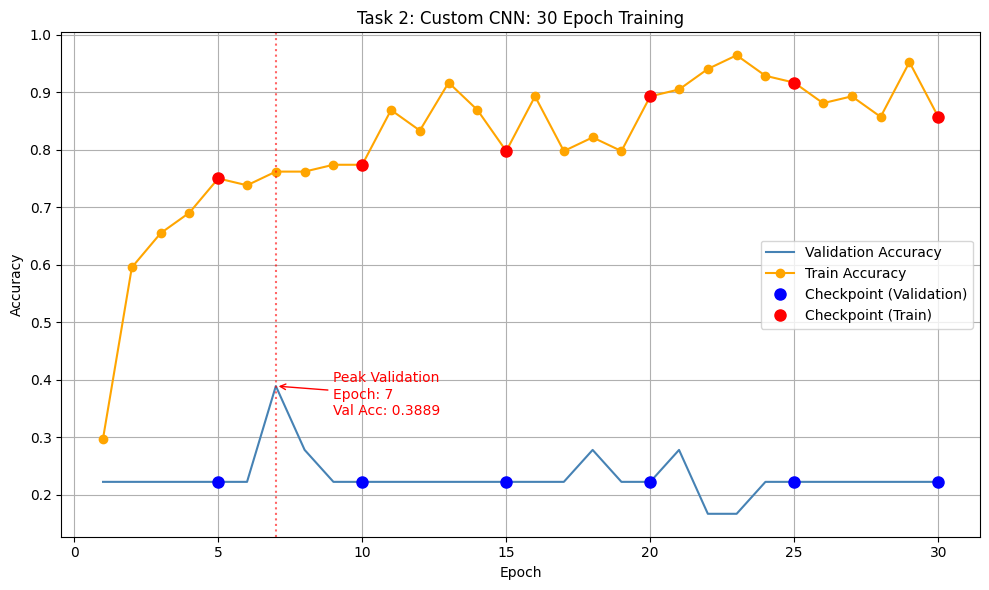

In [91]:
plot_history(history_cnn, "Task 2: Custom CNN")

## Task 3 — ResNet50 Feature Extraction

Load a pretrained ResNet50 (ImageNet weights) with the top layer removed. All backbone weights are frozen; only the newly added classification head (GlobalAveragePooling → Dense → Softmax) is trained.

In [92]:
set_all_seeds()

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model_fe = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.25),
    Dense(NUM_CLASSES, activation='softmax')
])

model_fe.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
trainable_params = sum(w.shape.num_elements() for w in model_fe.trainable_weights)
print(f"\nResNet50 (FE) — Trainable params: {trainable_params:,}")


ResNet50 (FE) — Trainable params: 262,917


In [101]:
print("Training ResNet50 (Feature Extraction)...")
history_fe = model_fe.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH,
    validation_data=(X_val, y_val),
    verbose=0
)

test_loss, test_acc_fe = model_fe.evaluate(X_test, y_test, verbose=0)
print(f"ResNet50 (FE) — Test Accuracy: {test_acc_fe:.4f}")

Training ResNet50 (Feature Extraction)...


KeyboardInterrupt: 

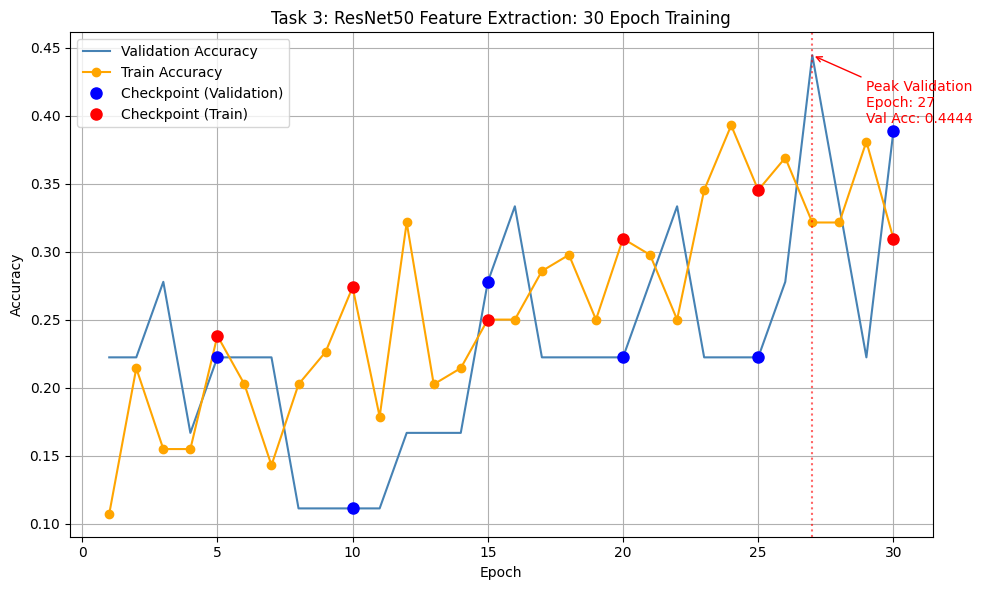

In [94]:
plot_history(history_fe, "Task 3: ResNet50 Feature Extraction")

## Task 4 — ResNet50 Fine-Tuning

Same ResNet50 backbone as Task 3, but the final convolutional block (last ~5 layers) is unfrozen for fine-tuning. A lower learning rate (1e-4) is used to avoid disrupting the learned feature representations.

In [95]:
set_all_seeds()

base_model_ft = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all but the last 5 layers (top of final bottleneck block)
for layer in base_model_ft.layers[:-5]:
    layer.trainable = False

model_ft = Sequential([
    base_model_ft,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.25),
    Dense(NUM_CLASSES, activation='softmax')
])

# Lower LR to protect pretrained weights
model_ft.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                 loss='categorical_crossentropy', metrics=['accuracy'])

trainable_params = sum(w.shape.num_elements() for w in model_ft.trainable_weights)
print(f"\nResNet50 (FT) — Trainable params: {trainable_params:,}")


ResNet50 (FT) — Trainable params: 1,317,637


In [96]:
print("Training ResNet50 (Fine-Tuning)...")
history_ft = model_ft.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH,
    validation_data=(X_val, y_val),
    verbose=0
)

test_loss, test_acc_ft = model_ft.evaluate(X_test, y_test, verbose=0)
print(f"ResNet50 (FT) — Test Accuracy: {test_acc_ft:.4f}")

Training ResNet50 (Fine-Tuning)...
ResNet50 (FT) — Test Accuracy: 0.3158


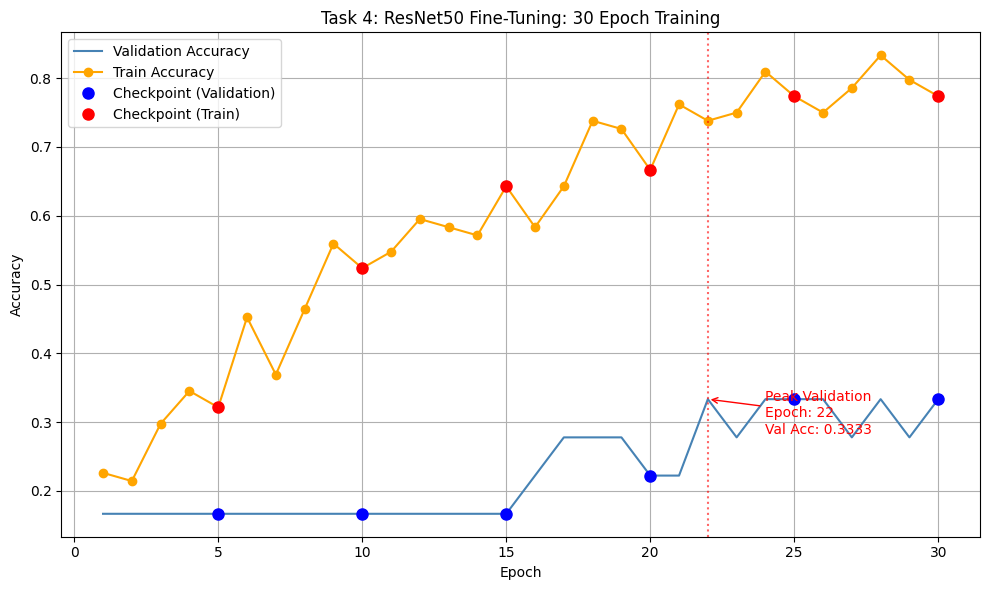

In [97]:
plot_history(history_ft, "Task 4: ResNet50 Fine-Tuning")

## Task 5 — Full Comparison

Produce a summary table comparing all three architectures on test accuracy and trainable parameter count. Display a side-by-side validation accuracy comparison.

In [98]:
summary_data = {
    'Architecture': ['Custom CNN', 'ResNet50 (Feature Extraction)', 'ResNet50 (Fine-Tuning)'],
    'Test Accuracy': [test_acc_cnn, test_acc_fe, test_acc_ft],
    'Trainable Parameters': [
        model_cnn.count_params(),
        sum(w.shape.num_elements() for w in model_fe.trainable_weights),
        sum(w.shape.num_elements() for w in model_ft.trainable_weights)
    ]
}
df = pd.DataFrame(summary_data)
print("\n--- Final Comparison Table ---")
display(df)


--- Final Comparison Table ---


,Architecture,Test Accuracy,Trainable Parameters
0,Custom CNN,0.210526,457413
1,ResNet50 (Feature Extraction),0.368421,262917
2,ResNet50 (Fine-Tuning),0.315789,1317637


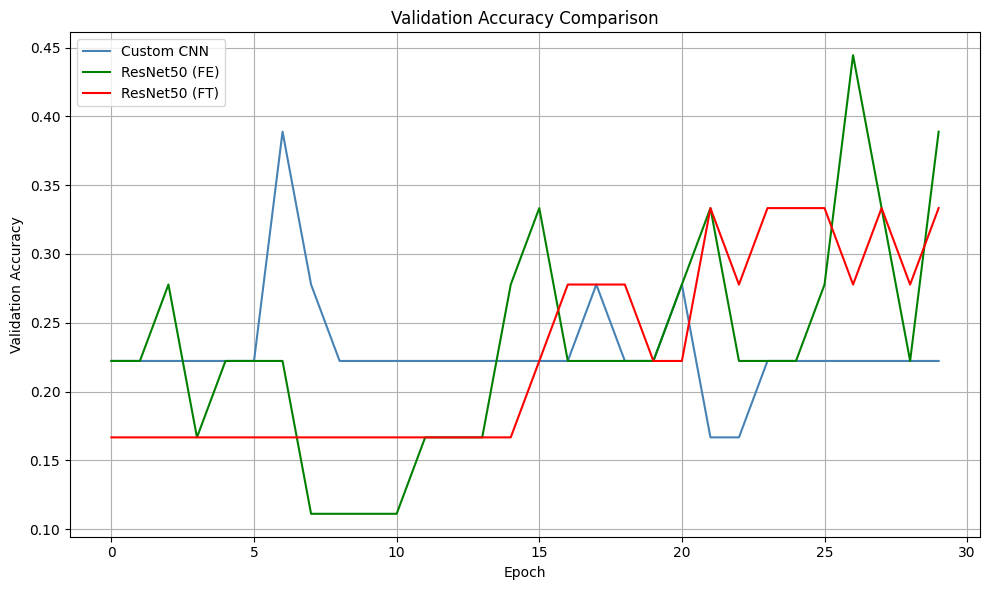

In [99]:
# Side-by-side validation accuracy comparison
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(history_cnn.history['val_accuracy'], color='steelblue', label='Custom CNN')
ax.plot(history_fe.history['val_accuracy'], color='green', label='ResNet50 (FE)')
ax.plot(history_ft.history['val_accuracy'], color='red', label='ResNet50 (FT)')

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Validation Accuracy Comparison')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## Conclusion

[Write-up: Compare the three architectures. Discuss how transfer learning (feature extraction vs fine-tuning) impacts accuracy and training speed on this small 5-class dataset. Note that with only ~25 images per class, pretrained features provide a significant advantage over training a CNN from scratch. The fine-tuning variant adapts those features to the specific identities, typically yielding the best accuracy at the cost of slightly more training compute.]